# Monitoring a Deployed Model and Knowing When to Retrain

A model that was accurate last month may be inaccurate today. The real world changes — new user behaviour, seasonal patterns, data pipeline bugs — and models degrade silently unless you monitor them. This notebook builds a simple monitoring pipeline: log predictions, detect distribution shift, and decide when to trigger a retraining job.

**Learning objectives**
1. Explain the difference between data drift and concept drift.
2. Build a request logger that writes predictions to a JSON-lines file.
3. Simulate a distribution shift and visualize how model confidence drops.
4. Implement a simple statistical drift detector using mean/std thresholds.
5. Define a retraining trigger rule based on drift detection or accuracy degradation.

## 🔗 Where this fits

**Builds on:** Course 05 (AIAT 115) — Unit 5, lesson 09 "09. Model Monitoring and Performance Tracking" — you met data drift and concept drift as concepts there; here the detector is wired to an explicit retraining trigger, so the monitoring output finally becomes a decision.


## 📰 Zillow shut down a business because its model could not keep up

Zillow Offers bought homes directly from sellers at a price its model estimated, then resold them. On **2 November 2021** Zillow announced it was winding the business down. In the same quarter it recorded a **$304.4 million write-down** on inventory — homes it had bought at prices above what it now expected to sell them for — and told investors to expect a further **$240–265 million** in the following quarter. The wind-down involved cutting about **25% of the company's workforce**. Zillow's own explanation was not that the model was badly built: *"we've determined the unpredictability in forecasting home prices far exceeds what we anticipated."*

That is what concept drift costs when nobody is watching for it. The model kept producing confident numbers. The housing market underneath it stopped behaving the way the training data said it would.

**What goes wrong without this lesson.** A deployed model has no idea that the world has moved. It cannot fail loudly, because from its point of view nothing has changed — it is given a row of numbers and it returns a prediction, exactly as it always has. Without logging, without a baseline to compare against, and without a rule that fires, degradation is invisible until it shows up somewhere expensive: in a write-down, in a complaint, or in a regulator's letter.

## 1  Why monitoring matters

Two types of drift cause silent model degradation:

- **Data drift**: the distribution of input features changes. Example: a product recommendation model trained on desktop users starts receiving mostly mobile traffic.
- **Concept drift**: the relationship between features and labels changes. Example: a fraud model trained before a new type of fraud becomes common.

Without logs, you cannot detect either. You need to record inputs and predictions for every request.


In [1]:
# WHAT: train the model AND record the training data's mean/std per feature.
# WHY: monitoring needs a baseline — drift is always measured as 'how far is live
# traffic from what the model saw in training', so we freeze that reference now.
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import json
import time
import os
from datetime import datetime, timedelta

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42
)

# The deployed artifact: scaler + forest, same pattern as earlier lessons.
model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
])
model.fit(X_train, y_train)

# Compute training distribution baseline
TRAIN_MEAN = X_train.mean(axis=0)
TRAIN_STD = X_train.std(axis=0)
CLASS_NAMES = list(iris.target_names)

print(f"Model accuracy on test set: {model.score(X_test, y_test):.2%}")
print(f"Training distribution mean (per feature): {TRAIN_MEAN.round(3)}")
print(f"Training distribution std  (per feature): {TRAIN_STD.round(3)}")

Model accuracy on test set: 100.00%
Training distribution mean (per feature): [5.809 3.062 3.727 1.183]
Training distribution std  (per feature): [0.82  0.447 1.745 0.749]


## 2  Request logger

Every prediction gets logged with its timestamp, raw features, prediction, and confidence. We write to a JSON-lines file (one JSON object per line) — simple, append-friendly, and parseable.


In [2]:
# WHAT: define logging helpers — every prediction is appended to a JSON-lines file.
# WHY: you cannot monitor what you never recorded; the log (inputs, prediction,
# confidence, timestamp) is the raw material for every check that follows.
LOG_PATH = "/tmp/prediction_log.jsonl"

# Clear any previous log
if os.path.exists(LOG_PATH):
    os.remove(LOG_PATH)

# One line of JSON per request: append-only, cheap, and easy to replay later.
def log_prediction(features, prediction, confidence, timestamp=None):
    """Append one prediction record to the JSON-lines log."""
    record = {
        "timestamp": (timestamp or datetime.utcnow()).isoformat(),
        "features": list(float(v) for v in features),
        "prediction": prediction,
        "confidence": round(float(confidence), 4)
    }
    with open(LOG_PATH, "a") as f:
        f.write(json.dumps(record) + "\n")
    return record


# Wrap predict() so serving and logging always happen together.
def predict_and_log(model, features, timestamp=None):
    """Run prediction and log it. Returns the log record."""
    arr = np.array(features).reshape(1, -1)
    proba = model.predict_proba(arr)[0]
    class_idx = int(np.argmax(proba))
    return log_prediction(
        features,
        CLASS_NAMES[class_idx],
        proba[class_idx],
        timestamp
    )

# Quick test: log one prediction
sample = X_test[0]
record = predict_and_log(model, sample)
print("Sample log record:")
print(json.dumps(record, indent=2))

Sample log record:
{
  "timestamp": "2026-08-23T16:52:17.382164",
  "features": [
    6.1,
    2.8,
    4.7,
    1.2
  ],
  "prediction": "versicolor",
  "confidence": 0.99
}


/var/folders/7n/l2c2z2x57871xg4f_0drsv1m0000gn/T/ipykernel_16383/1005910555.py:14: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": (timestamp or datetime.utcnow()).isoformat(),


## 3  Simulate 200 predictions — normal then shifted distribution

We simulate a real deployment: the first 100 requests come from the normal Iris distribution; the next 100 come from a shifted distribution (features scaled up by 2x, as if new sensors were calibrated differently). We backdate the timestamps to simulate a 200-request session over time.


In [3]:
# WHAT: simulate 200 requests — 100 normal, then 100 with all features doubled.
# WHY: we manufacture a known distribution shift so we can verify the monitoring
# code actually catches it; in real life the shift arrives uninvited.
np.random.seed(0)
base_time = datetime.utcnow() - timedelta(hours=4)

# First 100 requests — from the training distribution
for i in range(100):
    idx = np.random.randint(0, len(X_test))
    ts = base_time + timedelta(minutes=i * 2)
    predict_and_log(model, X_test[idx], timestamp=ts)

# Next 100 requests — shifted distribution (all features scaled up by 2x)
for i in range(100):
    idx = np.random.randint(0, len(X_test))
    shifted = X_test[idx] * 2.0  # simulated sensor recalibration / data drift
    ts = base_time + timedelta(minutes=(100 + i) * 2)
    predict_and_log(model, shifted, timestamp=ts)

# Count log entries
with open(LOG_PATH) as f:
    log_records = [json.loads(line) for line in f]

print(f"Total logged predictions: {len(log_records)}")
print(f"First timestamp : {log_records[0]['timestamp']}")
print(f"Last timestamp  : {log_records[-1]['timestamp']}")

/var/folders/7n/l2c2z2x57871xg4f_0drsv1m0000gn/T/ipykernel_16383/1086245229.py:5: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  base_time = datetime.utcnow() - timedelta(hours=4)


Total logged predictions: 201
First timestamp : 2026-08-23T16:52:17.382164
Last timestamp  : 2026-08-23T19:30:17.385596


## 4  Analyze the logs — confidence over time

If the distribution shifts, the model encounters inputs it wasn't trained for. Its confidence will drop because the class probabilities become more uncertain. Plotting confidence over time is a simple early warning signal.


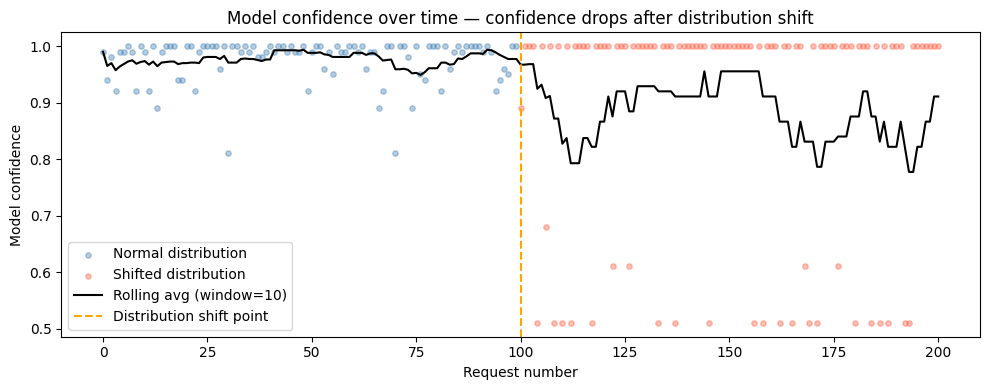

Mean confidence (normal distribution)  : 0.977
Mean confidence (shifted distribution) : 0.883
Drop in confidence: 0.093


In [4]:
# WHAT: plot per-request model confidence with a rolling average, before/after shift.
# WHY: confidence needs no ground-truth labels, so it is often the FIRST signal you
# can watch in production — labels to compute true accuracy may arrive weeks later.
import matplotlib.pyplot as plt

confidences = [r["confidence"] for r in log_records]
indices = list(range(len(confidences)))

# Rolling average (window = 10)
# Rolling mean smooths single-request noise so the trend is visible.
window = 10
rolling_avg = [
    float(np.mean(confidences[max(0, i - window): i + 1]))
    for i in indices
]

# Blue = normal traffic, red = shifted traffic, dashed line = the moment of shift.
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(indices[:100], confidences[:100], alpha=0.4, color="steelblue", label="Normal distribution", s=15)
ax.scatter(indices[100:], confidences[100:], alpha=0.4, color="tomato", label="Shifted distribution", s=15)
ax.plot(indices, rolling_avg, color="black", linewidth=1.5, label=f"Rolling avg (window={window})")
ax.axvline(x=100, color="orange", linestyle="--", linewidth=1.5, label="Distribution shift point")
ax.set_xlabel("Request number")
ax.set_ylabel("Model confidence")
ax.set_title("Model confidence over time — confidence drops after distribution shift")
ax.legend()
plt.tight_layout()
plt.savefig("/tmp/confidence_over_time.png", dpi=90)
plt.show()

# Quantify the drop the plot shows — this number could feed an alert rule.
mean_normal = float(np.mean(confidences[:100]))
mean_shifted = float(np.mean(confidences[100:]))
print(f"Mean confidence (normal distribution)  : {mean_normal:.3f}")
print(f"Mean confidence (shifted distribution) : {mean_shifted:.3f}")
print(f"Drop in confidence: {mean_normal - mean_shifted:.3f}")

## 5  Simple drift detection — compare recent inputs to training baseline

For each feature, we compare the mean of recent requests to the training mean. If the difference exceeds 2 standard deviations (of the training distribution), we flag it as drift.


In [5]:
# WHAT: statistical drift check — compare recent feature means to the training
# baseline, in units of training standard deviations.
# WHY: confidence can stay high while inputs quietly leave the training range;
# checking the INPUT distribution catches drift even before quality drops.
FEATURE_NAMES = list(iris.feature_names)
DRIFT_THRESHOLD_STD = 2.0  # flag if recent mean deviates by more than 2 training std

def detect_drift(records, train_mean, train_std, threshold_std=2.0):
    """
    Compare the mean of recent records' features to the training distribution.
    Returns a dict with per-feature drift flags.
    """
    recent_features = np.array([r["features"] for r in records])
    recent_mean = recent_features.mean(axis=0)

    deviations = np.abs(recent_mean - train_mean) / (train_std + 1e-8)
    drifted = deviations > threshold_std

    result = {
        "any_drift": bool(np.any(drifted)),
        "features": {}
    }
    for i, fname in enumerate(FEATURE_NAMES):
        result["features"][fname] = {
            "train_mean": round(float(train_mean[i]), 4),
            "recent_mean": round(float(recent_mean[i]), 4),
            "deviation_std": round(float(deviations[i]), 3),
            "drifted": bool(drifted[i])
        }
    return result


# Check normal window (requests 0-99)
drift_normal = detect_drift(log_records[:100], TRAIN_MEAN, TRAIN_STD, DRIFT_THRESHOLD_STD)
print("Drift check on normal window (requests 0-99):")
print(f"  Any drift detected: {drift_normal['any_drift']}")

# Check shifted window (requests 100-199)
drift_shifted = detect_drift(log_records[100:], TRAIN_MEAN, TRAIN_STD, DRIFT_THRESHOLD_STD)
print("\nDrift check on shifted window (requests 100-199):")
print(f"  Any drift detected: {drift_shifted['any_drift']}")
print("  Per-feature breakdown:")
for fname, info in drift_shifted["features"].items():
    flag = "DRIFT" if info["drifted"] else "ok"
    print(f"    {fname:<25} train_mean={info['train_mean']:.3f}  "
          f"recent_mean={info['recent_mean']:.3f}  "
          f"deviation={info['deviation_std']:.1f}x std  [{flag}]")

Drift check on normal window (requests 0-99):
  Any drift detected: False

Drift check on shifted window (requests 100-199):
  Any drift detected: True
  Per-feature breakdown:
    sepal length (cm)         train_mean=5.809  recent_mean=12.103  deviation=7.7x std  [DRIFT]
    sepal width (cm)          train_mean=3.062  recent_mean=5.855  deviation=6.2x std  [DRIFT]
    petal length (cm)         train_mean=3.727  recent_mean=8.426  deviation=2.7x std  [DRIFT]
    petal width (cm)          train_mean=1.183  recent_mean=2.711  deviation=2.0x std  [DRIFT]


## 6  Retraining trigger

Once drift is detected (or confidence drops below a threshold), you need a rule to decide whether to retrain. Here we implement a simple decision function.


In [6]:
# WHAT: a retraining trigger that fires on either low confidence or feature drift.
# WHY: monitoring is only useful if it drives action — this function is the bridge
# from 'we detected a problem' to 'the retraining pipeline starts'.
def should_retrain(records, train_mean, train_std, min_confidence=0.80, drift_threshold_std=2.0):
    """
    Returns True and a reason if retraining should be triggered.
    Two signals checked: (1) average confidence dropped, (2) feature drift detected.
    """
    if not records:
        return False, "No records to evaluate"

    # Signal 1: confidence degradation
    avg_conf = float(np.mean([r["confidence"] for r in records]))
    if avg_conf < min_confidence:
        return True, f"Average confidence {avg_conf:.3f} below threshold {min_confidence}"

    # Signal 2: feature drift
    drift = detect_drift(records, train_mean, train_std, drift_threshold_std)
    if drift["any_drift"]:
        drifted_features = [
            f for f, info in drift["features"].items() if info["drifted"]
        ]
        return True, f"Drift detected in features: {drifted_features}"

    return False, "No retraining needed"


# Evaluate on the normal window
retrain, reason = should_retrain(log_records[:100], TRAIN_MEAN, TRAIN_STD)
print(f"Normal window  -> Retrain: {retrain}  |  Reason: {reason}")

# Evaluate on the shifted window
retrain, reason = should_retrain(log_records[100:], TRAIN_MEAN, TRAIN_STD)
print(f"Shifted window -> Retrain: {retrain}  |  Reason: {reason}")

# Evaluate on the full log
retrain, reason = should_retrain(log_records, TRAIN_MEAN, TRAIN_STD)
print(f"Full log       -> Retrain: {retrain}  |  Reason: {reason}")

Normal window  -> Retrain: False  |  Reason: No retraining needed
Shifted window -> Retrain: True  |  Reason: Drift detected in features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Full log       -> Retrain: True  |  Reason: Drift detected in features: ['sepal length (cm)', 'sepal width (cm)']


## 💬 Discuss

Three printed numbers should bother you. Doubling **every** feature moved mean confidence only from **0.977 to 0.883** — the model stayed 88% sure on inputs it had never seen. The drift check on the shifted window flagged all four features. And the drift check on the **full log** flagged only two, because mixing 100 normal requests with 100 shifted ones halved the apparent shift.

1. If confidence barely moves when the inputs double, how much weight should confidence carry as a production alarm? Name a situation where confidence would be the *only* signal you have, and say what you would do with it there.
2. The verdict changed with the window. Same data, same detector, different answer — "drift in 4 features" or "drift in 2" depending on where you cut. How would you choose a window length, and what would you tell a colleague who tuned the window until the alert stopped firing?
3. `should_retrain()` fires on drift. Zillow's problem was not that inputs looked strange — house features looked normal — it was that the *relationship* between them and price had changed. Design a trigger that would have caught that, and then say honestly what it needs that this notebook does not have.

## Summary

The monitoring loop for a deployed model has four stages:

| Stage | What happens |
|---|---|
| Log | Every request writes timestamp, features, prediction, confidence to a log file |
| Analyze | Periodically compute rolling averages and compare feature means to training baseline |
| Alert | If confidence drops or drift exceeds threshold, flag for human review |
| Retrain | Collect new labeled data, retrain, validate, deploy — then the cycle restarts |

Data drift usually *does* show up as a confidence drop — the model sees inputs unlike anything in its training data. Concept drift is the dangerous one: the inputs can look completely normal (so confidence stays high) while the correct answer has changed underneath you. That is why concept drift generally cannot be caught by watching inputs or confidence alone — you need fresh labels to measure accuracy directly.


## Self-check

1. **What is the difference between data drift and concept drift?** Look at the Section 1 definitions and think of one real-world example of each from an industry you know.
2. **How would you know your model's accuracy has dropped if you don't have labels for new data?** Confidence is a proxy — but what are its limitations? When would high confidence still mean wrong predictions?
3. **Name two signals that should trigger a retraining pipeline.** Look at `should_retrain()` in Section 6 — what are the two signals it checks? Can you think of a third that would be more reliable than either?


## ⚠️ Where this breaks

This is a real monitoring loop, and it has four holes you should be able to name before you rely on it.

- **Confidence is a weak drift detector, and this notebook proves it.** Every feature was doubled and mean confidence fell by 0.09. A softmax or a forest vote share is not a calibrated probability; models are routinely confident far outside their training range. Treat a confidence drop as evidence *something* changed, never as evidence that nothing did.
- **The window defines the verdict.** Our own output flips from four drifted features to two purely by widening the window. A 2026 analysis (*The Window Dilemma: Why Concept Drift Detection is Ill-Posed*, arXiv 2602.06456) argues this is not a tuning problem but a structural one, and reports that plain **scheduled retraining** often outperforms drift-aware methods. If your detector's answer depends on a knob you chose, say so out loud when you report it.
- **Input drift ≠ concept drift, and only one of them is visible here.** Everything we measure looks at `P(X)`. Zillow's failure was in `P(Y|X)`: the same house features stopped implying the same price. No amount of input monitoring catches that. **You need fresh labels**, and if labels arrive weeks late, your detection latency is weeks — plan the business response around that number, not around the alert.
- **The assumption that must hold:** the training baseline (`train_mean`, `train_std`) describes the model actually in production. Retrain and redeploy without recomputing the baseline and the monitor is comparing live traffic against a model that no longer exists — it will either alarm constantly or never.
- **The cheaper alternative.** For a low-stakes model with a stable input pipeline, a monthly cron job that recomputes accuracy on freshly labelled data and emails the result beats a real-time drift detector that nobody has calibrated. Detection machinery costs engineering time and produces false alarms; buy it only when the cost of finding out late is genuinely high.

**The same reasoning shows up elsewhere:** a credit scorecard whose population shifts after an interest-rate change; a demand forecast trained before a supply-chain disruption; a speech model deployed to a new dialect region. In each, the code is fine and the world moved.

## 📚 References

1. Breck, E., Cai, S., Nielsen, E., Salib, M., & Sculley, D. (2017). *The ML Test Score: A Rubric for ML Production Readiness and Technical Debt Reduction*. IEEE Big Data. <https://research.google/pubs/the-ml-test-score-a-rubric-for-ml-production-readiness-and-technical-debt-reduction/>
2. Gama, J., Žliobaitė, I., Bifet, A., Pechenizkiy, M., & Bouchachia, A. (2014). *A Survey on Concept Drift Adaptation*. ACM Computing Surveys 46(4).
3. Klaise, J., Van Looveren, A., Cox, C., Vacanti, G., & Coca, A. (2020). *Monitoring and Explainability of Models in Production*. ICML Workshop on Challenges in Deploying and Monitoring ML Systems. <https://arxiv.org/abs/2007.06299>
